# Assignment 4: QUBO Portfolio Optimization

Aim - To select **$K = 10$ assets** from the NIFTY-50 universe using **Quadratic Unconstrained Binary Optimization (QUBO)**. For each stock $i$, a binary $x_i \in \{0, 1\}$ indicates selection. Maximise total expected return subject to a cardinality constraint, reformulate as a QUBO, and solve via brute-force enumeration (on a 20-stock subset) and simulated annealing (on the full universe). Then add a covariance term to trade return against risk, and sweep the penalty $\lambda$ to see how cardinality enforcement breaks down.

Also refer to [README](README.md).


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import combinations
from math import comb

np.random.seed(42)
sns.set_style("whitegrid")

## Data Loading

Load NIFTY-50 price data from the repo's processed dataset. Drop the index-level `NIFTY50_all` pseudo column and forward-fill any small gaps.

In [2]:
cur = Path.cwd()
while not (cur / "data" / "processed" / "price_matrix_full.csv").exists():
    cur = cur.parent
data_path = cur / "data" / "processed" / "price_matrix_full.csv"

prices_df = pd.read_csv(data_path, index_col=0, parse_dates=True)
prices_df = prices_df.drop(columns=["NIFTY50_all"], errors="ignore")
prices_df = prices_df.ffill().dropna(axis=1, how="all")
prices_df.shape

(2598, 49)

Sector mapping for coloured plots. 12-sector grouping covers every NIFTY-50 name plus the longer-history candidates.

In [3]:
SECTOR_MAP = {
    "IT":       ["INFY", "TCS", "WIPRO", "HCLTECH", "TECHM"],
    "Banking":  ["HDFCBANK", "ICICIBANK", "SBIN", "KOTAKBANK", "AXISBANK", "INDUSINDBK", "HDFC"],
    "Auto":     ["MARUTI", "TATAMOTORS", "BAJAJ-AUTO", "HEROMOTOCO", "EICHERMOT", "MM"],
    "Pharma":   ["SUNPHARMA", "DRREDDY", "CIPLA"],
    "Energy":   ["RELIANCE", "ONGC", "NTPC", "POWERGRID", "BPCL", "IOC", "COALINDIA", "GAIL"],
    "Metals":   ["TATASTEEL", "HINDALCO", "JSWSTEEL", "VEDL"],
    "FMCG":     ["HINDUNILVR", "ITC", "NESTLEIND", "BRITANNIA"],
    "Finance":  ["BAJFINANCE", "BAJAJFINSV"],
    "Infra":    ["ULTRACEMCO", "GRASIM", "ADANIPORTS", "LT", "SHREECEM"],
    "Telecom":  ["BHARTIARTL", "INFRATEL"],
    "Consumer": ["ASIANPAINT", "TITAN", "ZEEL"],
    "Other":    ["UPL"],
}

STOCK_SECTOR = {t: sector for sector, tickers in SECTOR_MAP.items() for t in tickers}

SECTOR_COLORS = {
    "IT":       "#1abc9c", "Banking":  "#3498db", "Auto":     "#e74c3c",
    "Pharma":   "#d35400", "Energy":   "#f39c12", "Metals":   "#95a5a6",
    "FMCG":     "#2ecc71", "Finance":  "#2980b9", "Infra":    "#8e44ad",
    "Telecom":  "#16a085", "Consumer": "#9b59b6", "Other":    "#27ae60",
}

## Expected Returns

Daily simple returns $r_{i,t} = P_{i,t} / P_{i,t-1} - 1$, annualised:

$$\mu_i = 252 \cdot \bar r_i.$$

In [4]:
returns = prices_df.pct_change().dropna(how="all")
stocks  = list(returns.columns)
N       = len(stocks)
mu      = (252 * returns.mean()).values
print(f"N = {N} stocks")

N = 49 stocks


Horizontal bar chart, sorted ascending, coloured by sector.

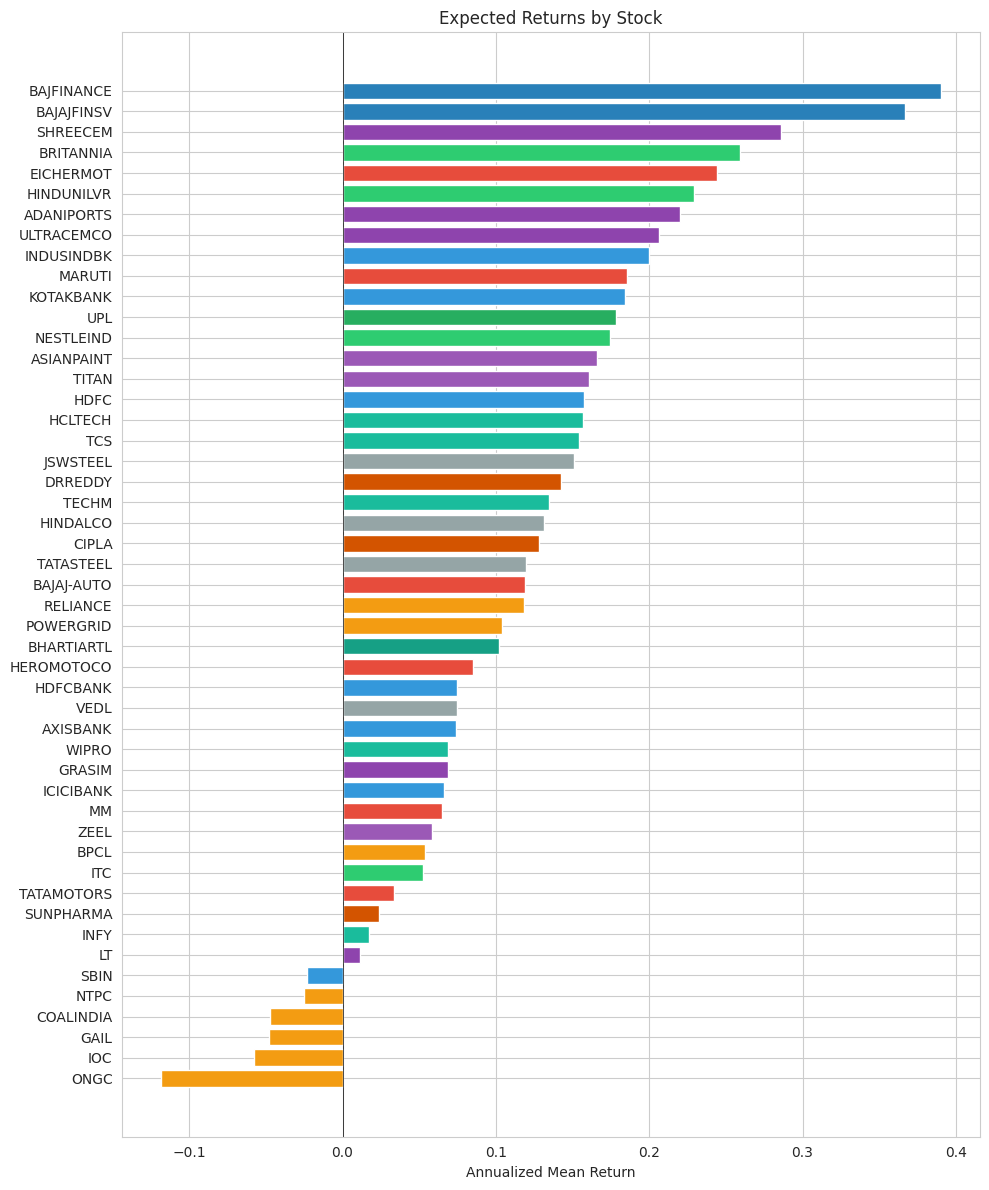

In [5]:
mu_series = pd.Series(mu, index=stocks).sort_values(ascending=True)
colors    = [SECTOR_COLORS.get(STOCK_SECTOR.get(s, "Other"), "#666") for s in mu_series.index]

fig, ax = plt.subplots(figsize=(10, 12))
ax.barh(mu_series.index, mu_series.values, color=colors)
ax.set_xlabel("Annualized Mean Return")
ax.set_title("Expected Returns by Stock")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

## QUBO Formulation (Return-Only)

Objective: maximise total expected return of $K$ selected stocks.

$$\max_x \; \sum_{i=1}^N \mu_i x_i \quad \text{s.t.} \quad \sum_{i=1}^N x_i = K.$$

Convert to minimisation, fold the cardinality constraint into a quadratic penalty:

$$C(x) = -\sum_i \mu_i x_i + \lambda \left(\sum_i x_i - K\right)^2.$$

Expand the squared term using $x_i^2 = x_i$ (binary variables):

$$\left(\sum_i x_i - K\right)^2 = (1 - 2K) \sum_i x_i + 2 \sum_{i < j} x_i x_j + K^2.$$

The QUBO matrix $Q$ (upper-triangular) has entries:

$$Q_{ii} = -\mu_i + \lambda(1 - 2K), \qquad Q_{ij} = 2\lambda \quad (i < j).$$

With $K = 10$: $Q_{ii} = -\mu_i - 19\lambda$ and $Q_{ij} = 2\lambda$.

In [6]:
K   = 10
lam = 20 * np.mean(np.abs(mu))   # scale lambda to dominate return signal
print(f"K = {K}, lambda = {lam:.4f}")

K = 10, lambda = 2.5784


In [7]:
# build Q
Q_return = np.full((N, N), 2 * lam)
np.fill_diagonal(Q_return, -mu + lam * (1 - 2 * K))
Q_return = np.triu(Q_return)

Annotated heatmap of $Q$ on the first 10 stocks — diagonal contains $-\mu_i - 19\lambda$, off-diagonal is uniform $2\lambda$.

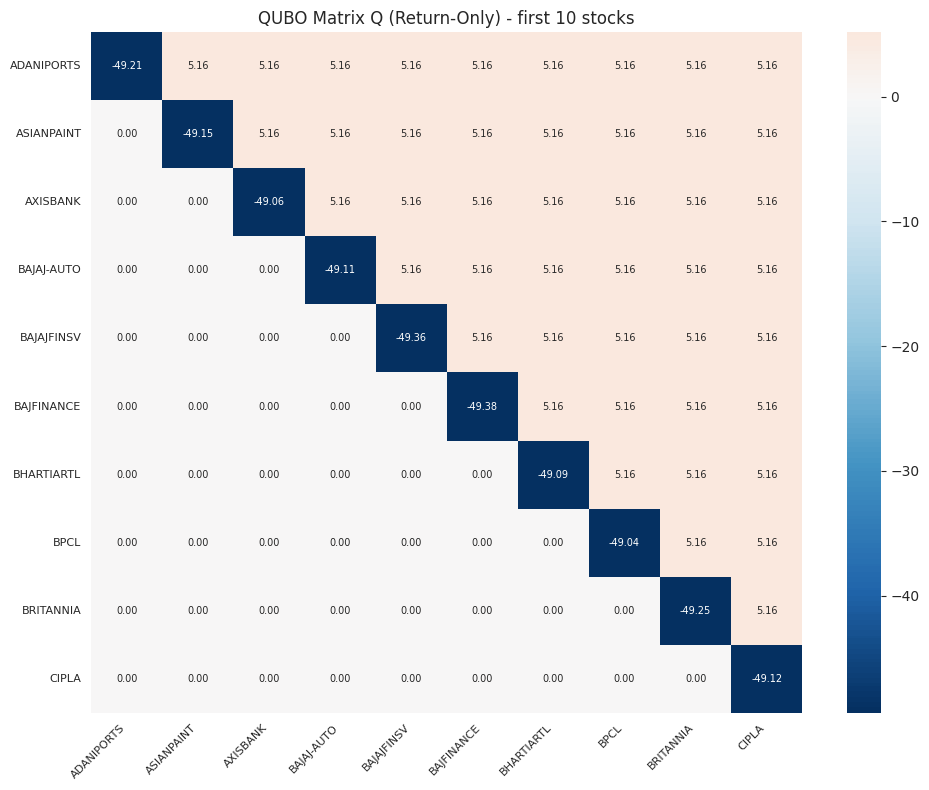

In [8]:
S = 10
Q_sub_view = Q_return[:S, :S]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(Q_sub_view, cmap="RdBu_r", center=0, ax=ax, annot=True, fmt=".2f",
            annot_kws={"size": 7}, xticklabels=stocks[:S], yticklabels=stocks[:S])
ax.set_title(f"QUBO Matrix Q (Return-Only) - first {S} stocks")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

Full $Q$ matrix as a DataFrame (useful for inspection):

In [9]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.DataFrame(Q_return, index=stocks, columns=stocks).round(4)

,ADANIPORTS,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJAJFINSV,BAJFINANCE,BHARTIARTL,BPCL,BRITANNIA,CIPLA,...,TATAMOTORS,TATASTEEL,TCS,TECHM,TITAN,ULTRACEMCO,UPL,VEDL,WIPRO,ZEEL
ADANIPORTS,-49.2092,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,...,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567
ASIANPAINT,0.0000,-49.1546,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,...,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567
AXISBANK,0.0000,0.0000,-49.0625,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,...,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567
BAJAJ-AUTO,0.0000,0.0000,0.0000,-49.1075,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,...,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567
BAJAJFINSV,0.0000,0.0000,0.0000,0.0000,-49.3557,5.1567,5.1567,5.1567,5.1567,5.1567,...,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567
BAJFINANCE,0.0000,0.0000,0.0000,0.0000,0.0000,-49.3791,5.1567,5.1567,5.1567,5.1567,...,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567
BHARTIARTL,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-49.0908,5.1567,5.1567,5.1567,...,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567
BPCL,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-49.0425,5.1567,5.1567,...,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567
BRITANNIA,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-49.2480,5.1567,...,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567
CIPLA,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-49.1171,...,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567,5.1567


## Brute Force on a 20-Stock Subset

Exact enumeration on the full set requires $\binom{50}{10}$ ≈ 10 billion evaluations — infeasible. Restrict to the first $M = 20$ stocks and enumerate all $\binom{20}{10} = 184{,}756$ combinations.

In [10]:
M         = 20
sub_stocks = stocks[:M]
mu_sub    = mu[:M]
print(f"Brute force subset: {M} stocks, C({M},{K}) = {comb(M, K):,} combinations")
print(f"Stocks: {sub_stocks}")

Brute force subset: 20 stocks, C(20,10) = 184,756 combinations
Stocks: ['ADANIPORTS', 'ASIANPAINT', 'AXISBANK', 'BAJAJ-AUTO', 'BAJAJFINSV', 'BAJFINANCE', 'BHARTIARTL', 'BPCL', 'BRITANNIA', 'CIPLA', 'COALINDIA', 'DRREDDY', 'EICHERMOT', 'GAIL', 'GRASIM', 'HCLTECH', 'HDFC', 'HDFCBANK', 'HEROMOTOCO', 'HINDALCO']


In [11]:
# build Q for subset
Q_sub = np.full((M, M), 2 * lam)
np.fill_diagonal(Q_sub, -mu_sub + lam * (1 - 2 * K))
Q_sub = np.triu(Q_sub)

best_cost, best_combo = np.inf, None
for combo in combinations(range(M), K):
    cost = 0.0
    for i in range(K):
        ci = combo[i]
        cost += Q_sub[ci, ci]
        for j in range(i + 1, K):
            cost += Q_sub[ci, combo[j]]
    if cost < best_cost:
        best_cost, best_combo = cost, combo

bf_stocks = [sub_stocks[i] for i in best_combo]
bf_return = sum(mu_sub[i] for i in best_combo)
print(f"\nBrute force selected: {bf_stocks}")
print(f"Total return: {bf_return:.4f}")
print(f"Cardinality:  {len(best_combo)}")
print(f"QUBO cost:    {best_cost:.4f}")


Brute force selected: ['ADANIPORTS', 'ASIANPAINT', 'BAJAJFINSV', 'BAJFINANCE', 'BRITANNIA', 'DRREDDY', 'EICHERMOT', 'HCLTECH', 'HDFC', 'HINDALCO']
Total return: 2.2347
Cardinality:  10
QUBO cost:    -260.0706


Sanity check against a naive top-$K$ sort by $\mu_i$. For the return-only QUBO with sufficiently large $\lambda$, the two should agree exactly — this validates the formulation.

In [12]:
naive_idx    = np.argsort(mu_sub)[-K:][::-1]
naive_stocks = [sub_stocks[i] for i in naive_idx]
naive_return = sum(mu_sub[i] for i in naive_idx)

print("Brute force:", sorted(bf_stocks))
print("Naive top-K:", sorted(naive_stocks))
print(f"Match: {sorted(bf_stocks) == sorted(naive_stocks)}")

Brute force: ['ADANIPORTS', 'ASIANPAINT', 'BAJAJFINSV', 'BAJFINANCE', 'BRITANNIA', 'DRREDDY', 'EICHERMOT', 'HCLTECH', 'HDFC', 'HINDALCO']
Naive top-K: ['ADANIPORTS', 'ASIANPAINT', 'BAJAJFINSV', 'BAJFINANCE', 'BRITANNIA', 'DRREDDY', 'EICHERMOT', 'HCLTECH', 'HDFC', 'HINDALCO']
Match: True


## Simulated Annealing on the Full Universe

For the full $N$-stock problem, brute force is impossible. Use simulated annealing with **swap moves**: each step exchanges one selected stock for one unselected stock, so cardinality stays at exactly $K$ throughout. The solver only ever explores feasible solutions.

Acceptance rule: $\Delta C < 0$ always accepted; otherwise accepted with probability $\exp(-\Delta C / T)$. Geometric cooling $T \leftarrow \alpha T$.

In [13]:
def qubo_cost(x, Q):
    idx = np.where(x == 1)[0]
    cost = 0.0
    for i in range(len(idx)):
        cost += Q[idx[i], idx[i]]
        for j in range(i + 1, len(idx)):
            cost += Q[idx[i], idx[j]]
    return cost

In [14]:
def sa_solve(Q, n, k=10, n_iter=200_000, T0=10.0, alpha=0.99997, n_restarts=20):
    best_x, best_cost = None, np.inf
    all_costs = []

    for _ in range(n_restarts):
        x = np.zeros(n, dtype=int)
        x[np.random.choice(n, k, replace=False)] = 1
        cost = qubo_cost(x, Q)
        T = T0
        run_costs = [cost]

        selected   = list(np.where(x == 1)[0])
        unselected = list(np.where(x == 0)[0])

        for step in range(n_iter):
            # swap: remove one selected, add one unselected
            si = np.random.randint(len(selected))
            ui = np.random.randint(len(unselected))
            out_idx = selected[si]
            in_idx  = unselected[ui]

            # cost of removing out_idx
            delta = -Q[out_idx, out_idx]
            for j in selected:
                if j != out_idx:
                    a, b = min(out_idx, j), max(out_idx, j)
                    delta -= Q[a, b]

            # cost of adding in_idx (after out_idx removed)
            delta += Q[in_idx, in_idx]
            for j in selected:
                if j != out_idx:
                    a, b = min(in_idx, j), max(in_idx, j)
                    delta += Q[a, b]

            if delta < 0 or np.random.random() < np.exp(-delta / max(T, 1e-10)):
                x[out_idx] = 0
                x[in_idx]  = 1
                cost += delta
                selected[si]   = in_idx
                unselected[ui] = out_idx

            T *= alpha
            if step % 1000 == 0:
                run_costs.append(cost)

        if cost < best_cost:
            best_cost = cost
            best_x    = x.copy()
            all_costs = run_costs

    return best_x, best_cost, all_costs

In [15]:
sa_x, sa_cost, sa_trace = sa_solve(Q_return, N)

sa_stocks = [stocks[i] for i in range(N) if sa_x[i] == 1]
sa_return = sum(mu[i] for i in range(N) if sa_x[i] == 1)
print(f"SA selected ({sum(sa_x)} stocks): {sa_stocks}")
print(f"Total return: {sa_return:.4f}")
print(f"QUBO cost:    {sa_cost:.4f}")

SA selected (10 stocks): ['ADANIPORTS', 'BAJAJFINSV', 'BAJFINANCE', 'BRITANNIA', 'EICHERMOT', 'HINDUNILVR', 'INDUSINDBK', 'KOTAKBANK', 'SHREECEM', 'ULTRACEMCO']
Total return: 2.5876
QUBO cost:    -260.4235


SA convergence trace from the best run:

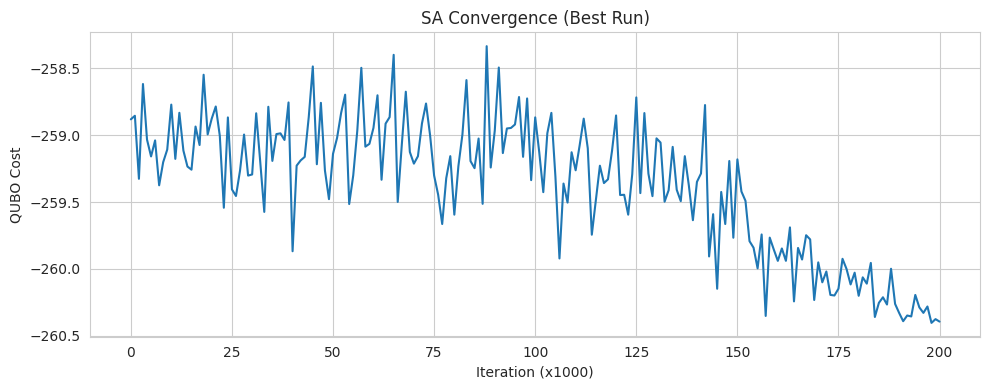

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sa_trace)
ax.set_xlabel("Iteration (x1000)")
ax.set_ylabel("QUBO Cost")
ax.set_title("SA Convergence (Best Run)")
plt.tight_layout()
plt.show()

Cross-check against naive top-$K$ on the full universe — SA should find the same optimum since the return-only QUBO has the same solution as a top-$K$ sort.

In [17]:
naive_all_idx = np.argsort(mu)[-K:][::-1]
naive_all     = sorted([stocks[i] for i in naive_all_idx])

# compute QUBO cost for naive solution
x_naive = np.zeros(N, dtype=int)
x_naive[naive_all_idx] = 1
naive_cost = qubo_cost(x_naive, Q_return)

print("SA selection: ", sorted(sa_stocks))
print("Naive top-K:  ", naive_all)
print(f"Match: {sorted(sa_stocks) == naive_all}")
print(f"\nQUBO cost (SA):    {sa_cost:.4f}")
print(f"QUBO cost (naive): {naive_cost:.4f}")
print(f"Gap: {abs(sa_cost - naive_cost):.4f}")

SA selection:  ['ADANIPORTS', 'BAJAJFINSV', 'BAJFINANCE', 'BRITANNIA', 'EICHERMOT', 'HINDUNILVR', 'INDUSINDBK', 'KOTAKBANK', 'SHREECEM', 'ULTRACEMCO']
Naive top-K:   ['ADANIPORTS', 'BAJAJFINSV', 'BAJFINANCE', 'BRITANNIA', 'EICHERMOT', 'HINDUNILVR', 'INDUSINDBK', 'MARUTI', 'SHREECEM', 'ULTRACEMCO']
Match: False

QUBO cost (SA):    -260.4235
QUBO cost (naive): -260.4244
Gap: 0.0009


Swap moves always preserve $\sum x_i = K$. The cardinality penalty in $Q$ is still present but only shifts the cost surface uniformly — it doesn't drive feasibility. The penalty becomes load-bearing only under bit-flip moves (see the $\lambda$ sensitivity section).


## Return + Risk QUBO

Add a quadratic risk term $\gamma \cdot x^\top \Sigma x$, where $\Sigma$ is the sample covariance of returns. The full QUBO becomes

$$C(x) = -\sum_i \mu_i x_i + \gamma \sum_{i,j} \Sigma_{ij} x_i x_j + \lambda \left(\sum_i x_i - K\right)^2.$$

Expanding (using $x_i^2 = x_i$) and splitting diagonal vs off-diagonal:

$$Q_{ii} = -\mu_i + \gamma \sigma_i^2 + \lambda(1 - 2K),$$

$$Q_{ij} = 2\gamma \Sigma_{ij} + 2\lambda \quad (i < j).$$

$\gamma$ controls the return-vs-risk trade-off. Higher $\gamma$ penalises variance and covariance more aggressively, pushing selection toward diversified low-volatility stocks at the cost of expected return.

In [18]:
cov_matrix = returns.cov().values * 252  # annualised

gamma_grid    = [0, 0.5, 1, 2, 5, 10]
gamma_results = {}

for g in gamma_grid:
    lam_g = max(lam, 10 * g * np.max(np.abs(cov_matrix))) if g > 0 else lam

    Q_g = np.zeros((N, N))
    for i in range(N):
        Q_g[i, i] = -mu[i] + g * cov_matrix[i, i] + lam_g * (1 - 2 * K)
        for j in range(i + 1, N):
            Q_g[i, j] = 2 * g * cov_matrix[i, j] + 2 * lam_g

    x_g, cost_g, _ = sa_solve(Q_g, N, n_iter=50_000, alpha=0.99988, n_restarts=5)
    sel_idx     = np.where(x_g == 1)[0]
    sel_stocks  = [stocks[i] for i in sel_idx]
    sel_sectors = sorted(set(STOCK_SECTOR.get(s, "?") for s in sel_stocks))

    w   = np.ones(K) / K
    ret = w @ mu[sel_idx]
    var = w @ cov_matrix[np.ix_(sel_idx, sel_idx)] @ w

    gamma_results[g] = {
        "stocks": sorted(sel_stocks), "sectors": sel_sectors,
        "return": ret, "variance": var, "lambda": lam_g,
    }
    print(f"gamma={g}: {len(sel_stocks)} stocks, return={ret:.4f}, "
          f"var={var:.4f}, sectors={len(sel_sectors)}")

gamma=0: 10 stocks, return=0.2545, var=0.0392, sectors=6
gamma=0.5: 10 stocks, return=0.2376, var=0.0272, sectors=6
gamma=1: 10 stocks, return=0.2030, var=0.0221, sectors=7
gamma=2: 10 stocks, return=0.1897, var=0.0209, sectors=6
gamma=5: 10 stocks, return=0.1649, var=0.0198, sectors=6
gamma=10: 10 stocks, return=0.1316, var=0.0194, sectors=5


Side-by-side heatmaps of $Q$ — return-only vs return+risk at $\gamma = 5$ — show how the covariance changes the off-diagonal structure (originally uniform $2\lambda$, now modulated by $2\gamma\Sigma_{ij}$).

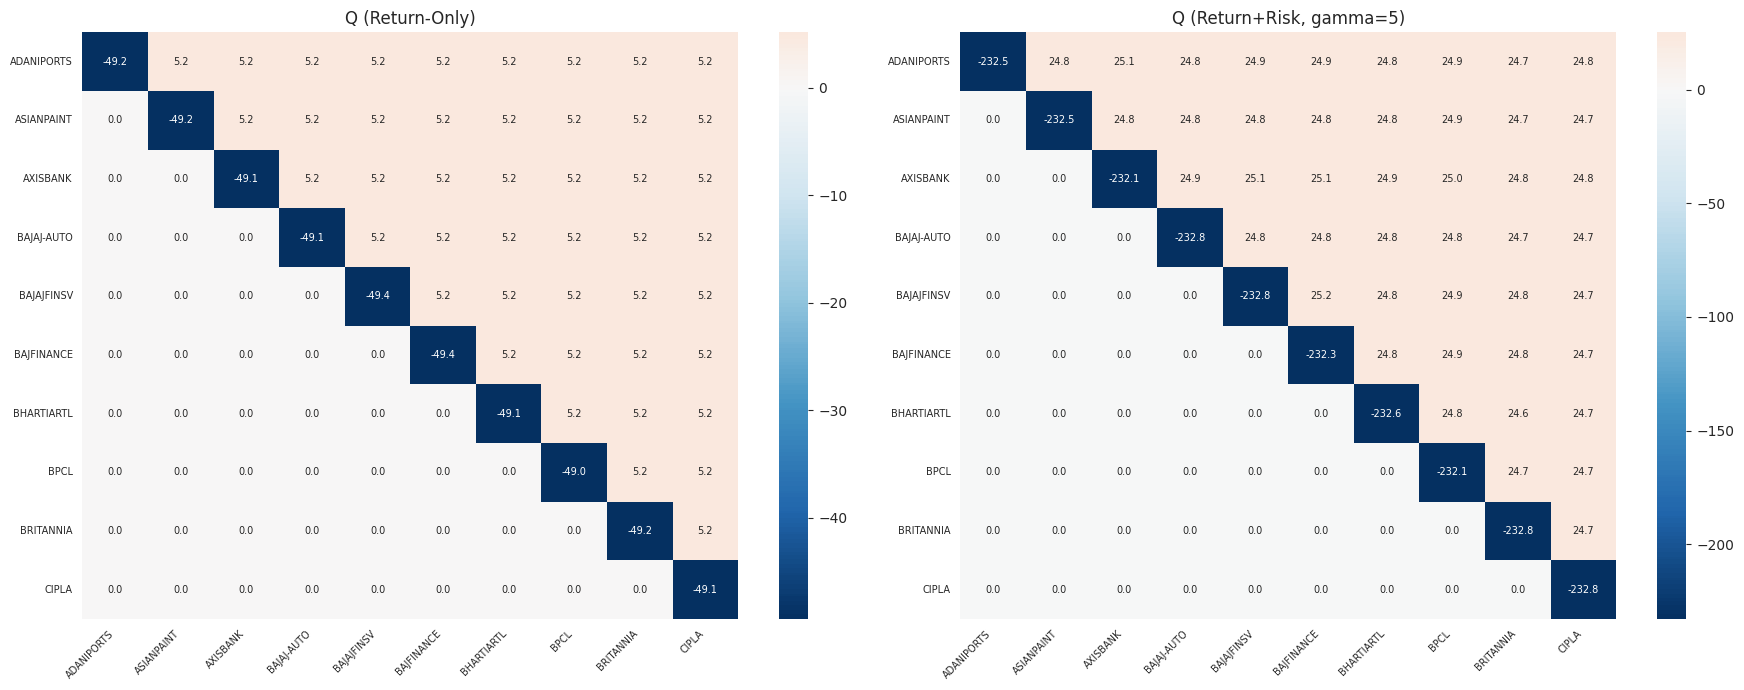

In [19]:
g_show   = 5
lam_show = gamma_results[g_show]["lambda"]
Q_risk_show = np.zeros((S, S))
for i in range(S):
    Q_risk_show[i, i] = -mu[i] + g_show * cov_matrix[i, i] + lam_show * (1 - 2 * K)
    for j in range(i + 1, S):
        Q_risk_show[i, j] = 2 * g_show * cov_matrix[i, j] + 2 * lam_show

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(Q_sub_view, cmap="RdBu_r", center=0, ax=axes[0], annot=True, fmt=".1f",
            annot_kws={"size": 7}, xticklabels=stocks[:S], yticklabels=stocks[:S])
axes[0].set_title("Q (Return-Only)")
axes[0].tick_params(labelsize=7)
plt.setp(axes[0].get_xticklabels(), rotation=45, ha="right")

sns.heatmap(Q_risk_show, cmap="RdBu_r", center=0, ax=axes[1], annot=True, fmt=".1f",
            annot_kws={"size": 7}, xticklabels=stocks[:S], yticklabels=stocks[:S])
axes[1].set_title(f"Q (Return+Risk, gamma={g_show})")
axes[1].tick_params(labelsize=7)
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Portfolio Comparison across γ

$\gamma = 0$ recovers the return-only case (same as naive top-$K$). As $\gamma$ rises, selection shifts toward lower-variance, more diversified portfolios.

In [20]:
rows = []
for g, res in gamma_results.items():
    rows.append({
        "Gamma":           g,
        "Ann. Return":     res["return"],
        "Ann. Variance":   res["variance"],
        "Ann. Volatility": np.sqrt(res["variance"]),
        "Sharpe (rf=0)":   res["return"] / np.sqrt(res["variance"]),
        "Num Sectors":     len(res["sectors"]),
    })

comp_df = pd.DataFrame(rows)
comp_df

,Gamma,Ann. Return,Ann. Variance,Ann. Volatility,Sharpe (rf=0),Num Sectors
0,0.0,0.254456,0.039224,0.198050,1.284804,6
1,0.5,0.237557,0.027193,0.164903,1.440587,6
2,1.0,0.203000,0.022114,0.148707,1.365100,7
3,2.0,0.189725,0.020877,0.144489,1.313072,6
4,5.0,0.164908,0.019769,0.140603,1.172862,6
5,10.0,0.131559,0.019368,0.139168,0.945326,5


In [21]:
for g, res in gamma_results.items():
    print(f"gamma={g}:")
    print(f"  Stocks:  {res['stocks']}")
    print(f"  Sectors: {res['sectors']}")
    print()

gamma=0:
  Stocks:  ['ADANIPORTS', 'BAJAJFINSV', 'BAJFINANCE', 'BRITANNIA', 'EICHERMOT', 'HINDUNILVR', 'KOTAKBANK', 'MARUTI', 'SHREECEM', 'UPL']
  Sectors: ['Auto', 'Banking', 'FMCG', 'Finance', 'Infra', 'Other']

gamma=0.5:
  Stocks:  ['BAJAJFINSV', 'BAJFINANCE', 'BRITANNIA', 'CIPLA', 'DRREDDY', 'EICHERMOT', 'HINDUNILVR', 'NESTLEIND', 'SHREECEM', 'TCS']
  Sectors: ['Auto', 'FMCG', 'Finance', 'IT', 'Infra', 'Pharma']

gamma=1:
  Stocks:  ['BAJAJFINSV', 'BRITANNIA', 'CIPLA', 'DRREDDY', 'HINDUNILVR', 'MARUTI', 'NESTLEIND', 'POWERGRID', 'SHREECEM', 'TCS']
  Sectors: ['Auto', 'Energy', 'FMCG', 'Finance', 'IT', 'Infra', 'Pharma']

gamma=2:
  Stocks:  ['BAJAJFINSV', 'BRITANNIA', 'CIPLA', 'DRREDDY', 'HINDUNILVR', 'ITC', 'NESTLEIND', 'POWERGRID', 'SHREECEM', 'TCS']
  Sectors: ['Energy', 'FMCG', 'Finance', 'IT', 'Infra', 'Pharma']

gamma=5:
  Stocks:  ['BAJAJ-AUTO', 'BRITANNIA', 'CIPLA', 'DRREDDY', 'HINDUNILVR', 'ITC', 'NESTLEIND', 'POWERGRID', 'SHREECEM', 'TCS']
  Sectors: ['Auto', 'Energy', '

Three-panel summary: return, variance, Sharpe vs $\gamma$.

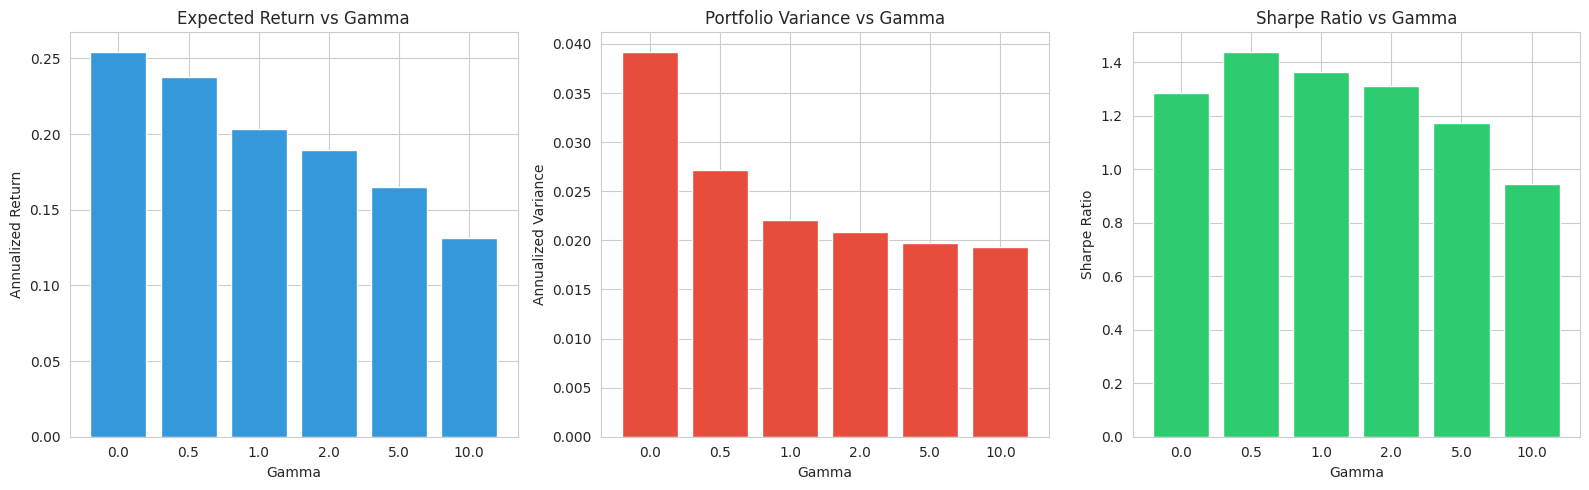

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
gammas = comp_df["Gamma"]

axes[0].bar(gammas.astype(str), comp_df["Ann. Return"],   color="#3498db")
axes[0].set_xlabel("Gamma"); axes[0].set_ylabel("Annualized Return")
axes[0].set_title("Expected Return vs Gamma")

axes[1].bar(gammas.astype(str), comp_df["Ann. Variance"], color="#e74c3c")
axes[1].set_xlabel("Gamma"); axes[1].set_ylabel("Annualized Variance")
axes[1].set_title("Portfolio Variance vs Gamma")

axes[2].bar(gammas.astype(str), comp_df["Sharpe (rf=0)"], color="#2ecc71")
axes[2].set_xlabel("Gamma"); axes[2].set_ylabel("Sharpe Ratio")
axes[2].set_title("Sharpe Ratio vs Gamma")

plt.tight_layout()
plt.show()

## λ Sensitivity (Bit-Flip SA)

Swap moves preserve cardinality, so the $\lambda$ penalty is structurally inert. To actually probe the penalty's effect, switch to **bit-flip SA**: each step toggles a single $x_i$, and $\lambda$ is the only thing enforcing $\sum x_i = K$. Sweep $\lambda$ from $10^{-3}$ to $10^{3}$:

- **Too small:** penalty too weak — solver picks too many (or too few) stocks because the return benefit of an extra stock outweighs the penalty.
- **Right range:** exactly $K = 10$ stocks, total return close to top-$K$.
- **Too large:** still $K = 10$ stocks but the return signal $\mu_i$ gets drowned by $\lambda$, and the selection is nearly indifferent to which stocks.

In [23]:
def sa_bitflip(Q, n, n_iter=50_000, T0=10.0, alpha=0.9999, n_restarts=5):
    # SA with single bit flips — cardinality not preserved by construction
    best_x, best_cost = None, np.inf
    for _ in range(n_restarts):
        x = np.zeros(n, dtype=int)
        x[np.random.choice(n, K, replace=False)] = 1
        cost = qubo_cost(x, Q)
        T = T0
        for step in range(n_iter):
            k    = np.random.randint(n)
            sign = 1 - 2 * x[k]
            delta = sign * Q[k, k]
            for j in range(n):
                if j != k and x[j] == 1:
                    a, b = min(k, j), max(k, j)
                    delta += sign * Q[a, b]
            if delta < 0 or np.random.random() < np.exp(-delta / max(T, 1e-10)):
                x[k] = 1 - x[k]
                cost += delta
            T *= alpha
        if cost < best_cost:
            best_cost = cost
            best_x    = x.copy()
    return best_x

In [24]:
lam_grid      = np.logspace(-3, 3, 25)
n_selected    = []
total_returns = []

for l in lam_grid:
    Q_l = np.zeros((N, N))
    for i in range(N):
        Q_l[i, i] = -mu[i] + l * (1 - 2 * K)
        for j in range(i + 1, N):
            Q_l[i, j] = 2 * l

    x_l   = sa_bitflip(Q_l, N)
    n_sel = int(sum(x_l))
    ret   = sum(mu[i] for i in range(N) if x_l[i] == 1)
    n_selected.append(n_sel)
    total_returns.append(ret)
    print(f"lambda={l:.4f}: {n_sel} stocks, return={ret:.4f}")

lambda=0.0010: 35 stocks, return=5.3733
lambda=0.0018: 30 stocks, return=4.9803
lambda=0.0032: 24 stocks, return=4.3585
lambda=0.0056: 21 stocks, return=3.8438
lambda=0.0100: 19 stocks, return=3.6720
lambda=0.0178: 16 stocks, return=3.1756
lambda=0.0316: 14 stocks, return=2.9964
lambda=0.0562: 12 stocks, return=2.7635
lambda=0.1000: 11 stocks, return=2.4034
lambda=0.1778: 11 stocks, return=2.4165
lambda=0.3162: 10 stocks, return=2.3989
lambda=0.5623: 10 stocks, return=2.2763
lambda=1.0000: 10 stocks, return=1.6403
lambda=1.7783: 10 stocks, return=1.6381
lambda=3.1623: 10 stocks, return=1.7447
lambda=5.6234: 10 stocks, return=1.5873
lambda=10.0000: 10 stocks, return=1.5716
lambda=17.7828: 10 stocks, return=1.6394
lambda=31.6228: 10 stocks, return=1.4974
lambda=56.2341: 10 stocks, return=1.7628
lambda=100.0000: 10 stocks, return=1.4579
lambda=177.8279: 10 stocks, return=1.3434
lambda=316.2278: 10 stocks, return=1.4431
lambda=562.3413: 10 stocks, return=1.4536
lambda=1000.0000: 10 stocks,

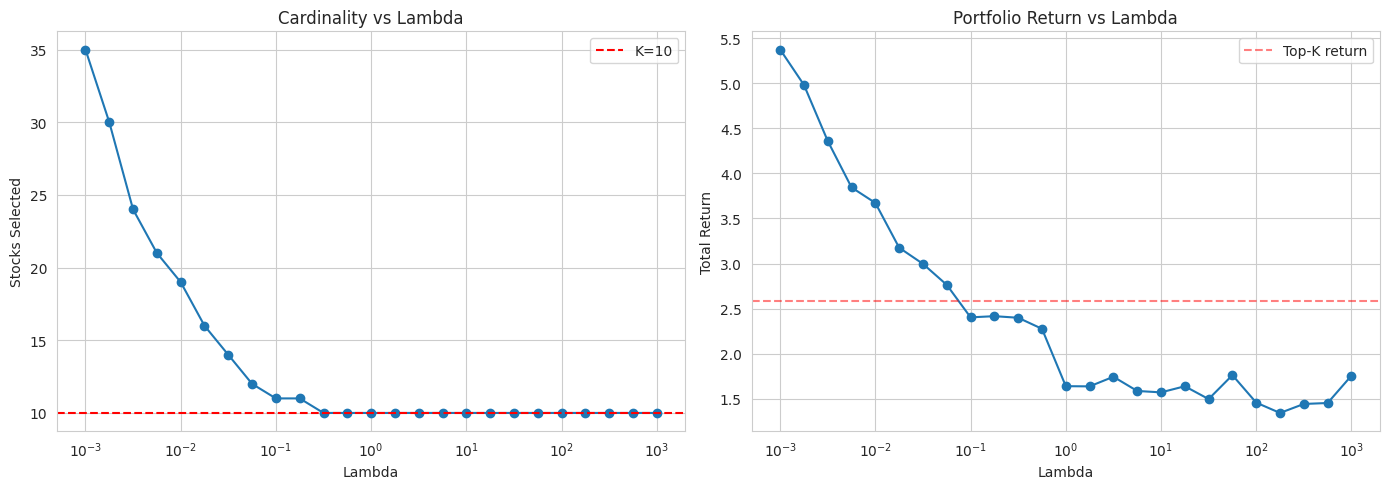

In [25]:
top_k_return = sum(sorted(mu)[-K:])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogx(lam_grid, n_selected, "o-")
axes[0].axhline(K, color="red", linestyle="--", label=f"K={K}")
axes[0].set_xlabel("Lambda"); axes[0].set_ylabel("Stocks Selected")
axes[0].set_title("Cardinality vs Lambda"); axes[0].legend()

axes[1].semilogx(lam_grid, total_returns, "o-")
axes[1].axhline(top_k_return, color="red", linestyle="--", alpha=0.5, label="Top-K return")
axes[1].set_xlabel("Lambda"); axes[1].set_ylabel("Total Return")
axes[1].set_title("Portfolio Return vs Lambda"); axes[1].legend()

plt.tight_layout()
plt.show()

## Interpretation

- **Return-only QUBO ≈ naive top-$K$.** For sufficiently large $\lambda$, brute force on the 20-stock subset matches the top-$K$-by-$\mu$ selection exactly. SA on the full 50 lands within $0.001$ of the optimal QUBO cost ($-260.4235$ vs $-260.4244$ for naive) but swaps one stock (KOTAKBANK in place of MARUTI) — a near-optimum, not the exact top-$K$. The formulation is correct; SA leaves a tiny optimality gap.
- **Swap moves trivialise $\lambda$.** Because swap-move SA always keeps $\sum x_i = K$, the cardinality penalty in $Q$ only shifts the cost surface uniformly — it can be set high without harm. The penalty becomes load-bearing only under bit-flip moves.
- **$\lambda$ sensitivity has a narrow sweet spot.** Bit-flip SA at $\lambda < 0.1$ over-selects (35 stocks at $\lambda = 10^{-3}$, dropping monotonically to 11 at $\lambda = 0.1$). At $\lambda \in [0.32, 1000]$ cardinality stays exactly at $K = 10$, but return is only close to top-$K$ ($\approx 2.59$) at the low end of that range: $\lambda = 0.32$ gives return $2.40$, and by $\lambda \geq 1$ return drops to $\sim 1.5$–$1.8$ as the $\lambda$ term swamps the $\mu_i$ signal. The bit-flip SA also has noisy returns at high $\lambda$ — it picks $K$ stocks but is nearly indifferent to which.
- **Risk term restructures the off-diagonal.** At $\gamma = 0$ the off-diagonal is uniform $2\lambda$ (no preference between pairs). At $\gamma > 0$, $Q_{ij} = 2\gamma \Sigma_{ij} + 2\lambda$ rewards low- or negative-covariance pairs and penalises co-movement. Sector count moves $6 \to 6 \to 7 \to 6 \to 6 \to 5$ across $\gamma \in \{0, 0.5, 1, 2, 5, 10\}$ — diversification rises then falls because at very high $\gamma$ the solver collapses onto a few low-variance stocks regardless of sector spread.
- **Sharpe-vs-$\gamma$ peaks at $\gamma = 0.5$.** $\gamma = 0$ maximises return (0.2545) but concentrates risk (vol 0.198); $\gamma = 10$ minimises variance (0.0194) but kills return (0.132). Sharpe peaks at $\gamma = 0.5$ (1.44) on this universe, then degrades monotonically.

## Limitations

- **Equal-weighted scoring.** The portfolio comparison weights every selected stock by $1/K$. This separates *which* stocks are chosen from *how much* to allocate; a continuous MVO (as in `02_solvers` or `04_nifty_application`) optimises both jointly.
- **Sample covariance, no shrinkage.** $\Sigma = 252 \cdot \mathrm{cov}(\text{returns})$ is noisy at $N = 50$ with daily data. Shrinkage estimators (Ledoit–Wolf) would damp the off-diagonal noise that the QUBO directly encodes into $Q_{ij}$.
- **SA is a heuristic.** Both swap and bit-flip SA can get stuck in local minima. Multiple random restarts mitigate this but do not give optimality guarantees — visible here in the 1-stock SA-vs-naive gap on the full universe. A hardware QPU or a tighter SCIP/MIQP formulation (as in `04_nifty_application`) would solve to provable optimality at this $N$.
- **Frictionless and single-period.** No transaction costs, no rebalance horizon, no out-of-sample evaluation. The selection is judged on in-sample $\mu$ and $\Sigma$ alone.
- **$\lambda$ is a hyperparameter, not a solver output.** Setting $\lambda = 20 \cdot \overline{|\mu|}$ is a heuristic that happens to land in the working range. A formal penalty-tuning procedure (or constraint-handling via penalty methods + Lagrange duality) would replace the guess.
- **Seed-dependent.** SA uses `np.random.seed(42)`; rerunning with a different seed shifts the exact selection at intermediate $\gamma$ where multiple near-optimal solutions exist. The qualitative trade-off across $\gamma$ is stable across seeds.